In [1]:
!pip install scapy
!pip install mocket

In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
import socket
from scapy.all import sniff
from unittest.mock import patch
import random
import pickle
from joblib import dump, load

In [3]:
df = pd.read_csv("/content/KDDTrain+.txt")

columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'])

df.columns = columns
df.head()
df = df.drop('level', axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125972.0,287.146929,2.604526e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125972.0,45567.100824,5.870354e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125972.0,19779.271433,4.021285e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125972.0,0.000198,1.408613e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125972.0,0.022688,2.535310e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125972.0,0.000111,1.436608e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125972.0,0.204411,2.149977e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125972.0,0.001222,4.523932e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125972.0,0.395739,4.890107e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125972.0,0.279253,2.394214e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [6]:
df['attack'].unique()

array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'ftp_write', 'multihop', 'rootkit',
       'buffer_overflow', 'imap', 'warezmaster', 'phf', 'land',
       'loadmodule', 'spy', 'perl'], dtype=object)

In [7]:
# changing attack labels to their respective attack class
def change_label(df):
    df.attack.replace(['apache2','back','land','neptune','mailbomb','pod',
	'processtable','smurf','teardrop','udpstorm','worm'],'Dos',inplace=True)
    df.attack.replace(['ftp_write','guess_passwd','httptunnel','imap','multihop','named',
	'phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock',
	'xsnoop'],'R2L',inplace=True)
    df.attack.replace(['ipsweep','mscan','nmap','portsweep','saint','satan']
	,'Probe',inplace=True)
    df.attack.replace(['buffer_overflow','loadmodule','perl','ps','rootkit',
	'sqlattack','xterm'],'U2R',inplace=True)

In [8]:
change_label(df)
df.attack.unique()

array(['normal', 'Dos', 'R2L', 'Probe', 'U2R'], dtype=object)

In [9]:
df.attack.value_counts()

,count
attack,
normal,67342
Dos,45927
Probe,11656
R2L,995
U2R,52


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from imblearn.over_sampling import ADASYN

In [11]:
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()

le_protocol_type = le1.fit(df['protocol_type'])
le_service = le2.fit(df['service'])
le_flag = le3.fit(df['flag'])

le_attack = le4.fit(df['attack'])
df['protocol_type'] = le_protocol_type.transform(df['protocol_type'])
df['service'] = le_service.transform(df['service'])
df['flag'] = le_flag.transform(df['flag'])

df['attack'] = le_attack.transform(df['attack'])

In [12]:
df.service.unique()

array([44, 49, 24, 51, 20, 36, 38, 14, 35, 60, 18, 12, 58, 67,  2, 54,  7,
       66, 37, 65,  4, 11, 19,  5, 32, 15, 21, 68, 59, 26, 16, 69, 28, 29,
       13, 30, 33, 57, 34, 31, 55, 63, 23, 17, 43, 10, 42,  6,  8, 56,  9,
       53, 40, 47, 41,  0, 46, 48, 62, 45, 50, 39, 52,  1, 64, 27,  3, 25,
       61, 22])

In [13]:
y= df[['attack']]
X= df.drop(labels=['attack'], axis=1)

print('X_train has shape:',X.shape,'\ny_train has shape:',y.shape)

X_train has shape: (125972, 41) 
y_train has shape: (125972, 1)


In [14]:
# 1. Split FIRST — before any scaling or resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [15]:
# 2. Fit scaler on TRAIN only, apply to both
numerical_columns = X_train.select_dtypes(include=np.number).columns
scaler = MinMaxScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [16]:
# 3. ADASYN on TRAIN only — test set stays untouched, real-world distribution
adasyn = ADASYN(random_state=42)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

print('Train shape after resampling:', X_train.shape)
print('Test shape (untouched, real distribution):', X_test.shape)

Train shape after resampling: (269476, 41)
Test shape (untouched, real distribution): (25195, 41)


In [17]:
target_names = list(le_attack.classes_)

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

In [19]:
from xgboost import XGBClassifier
xg = XGBClassifier(n_estimators=200, learning_rate=0.1,maxdepth = 6, objective='multi:softmax', random_state=42)
xg = xg.fit(X_train, y_train)

In [20]:
xg_pred = xg.predict(X_test)
xg_pred

array([0, 0, 0, ..., 4, 4, 0], dtype=int32)

In [21]:
xg_acc = accuracy_score(y_test, xg_pred)
xg_acc * 100

99.91268108751737

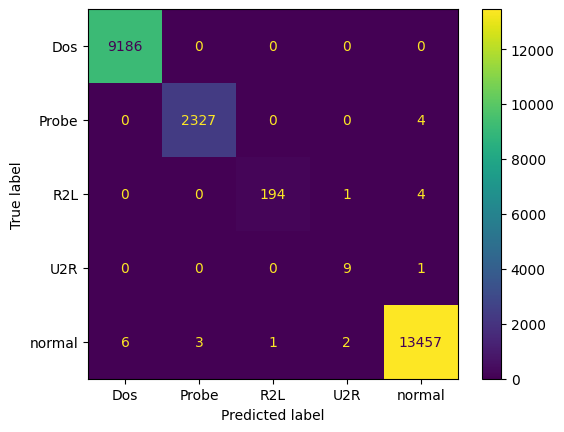

In [22]:
xg_cm = confusion_matrix(y_test, xg_pred)
ConfusionMatrixDisplay(xg_cm,display_labels=target_names).plot()

In [23]:
print(classification_report(y_test, xg_pred, target_names=target_names))

              precision    recall  f1-score   support

         Dos       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      0.97      0.98       199
         U2R       0.75      0.90      0.82        10
      normal       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       0.95      0.97      0.96     25195
weighted avg       1.00      1.00      1.00     25195



In [24]:
print(le_attack.classes_)

['Dos' 'Probe' 'R2L' 'U2R' 'normal']


    ['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm']Dos
    ['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop']R2L      
    ['ipsweep','mscan','nmap','portsweep','saint','satan']Probe
    ['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'],U2R

In [34]:
train_pred = xg.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, xg_pred))

Train accuracy: 0.9999777345663435
Test accuracy: 0.9991268108751736


In [35]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xg, X_train, y_train, cv=5, scoring='f1_macro')
print("CV F1 scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV F1 scores: [0.98353267 0.99786565 0.98754975 0.99933192 0.99577435]
Mean: 0.9928108666608345 Std: 0.006174489882402438


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest accuracy:", rf_acc)
print()
print(classification_report(y_test, rf_pred, target_names=target_names))

Random Forest accuracy: 0.9792816034927565

              precision    recall  f1-score   support

         Dos       1.00      1.00      1.00      9186
       Probe       0.92      1.00      0.96      2331
         R2L       0.42      0.98      0.59       199
         U2R       0.25      1.00      0.40        10
      normal       1.00      0.96      0.98     13469

    accuracy                           0.98     25195
   macro avg       0.72      0.99      0.79     25195
weighted avg       0.99      0.98      0.98     25195



In [37]:
print(f"XGBoost accuracy:      {xg_acc:.4f}")
print(f"Random Forest accuracy: {rf_acc:.4f}")

XGBoost accuracy:      0.9991
Random Forest accuracy: 0.9793


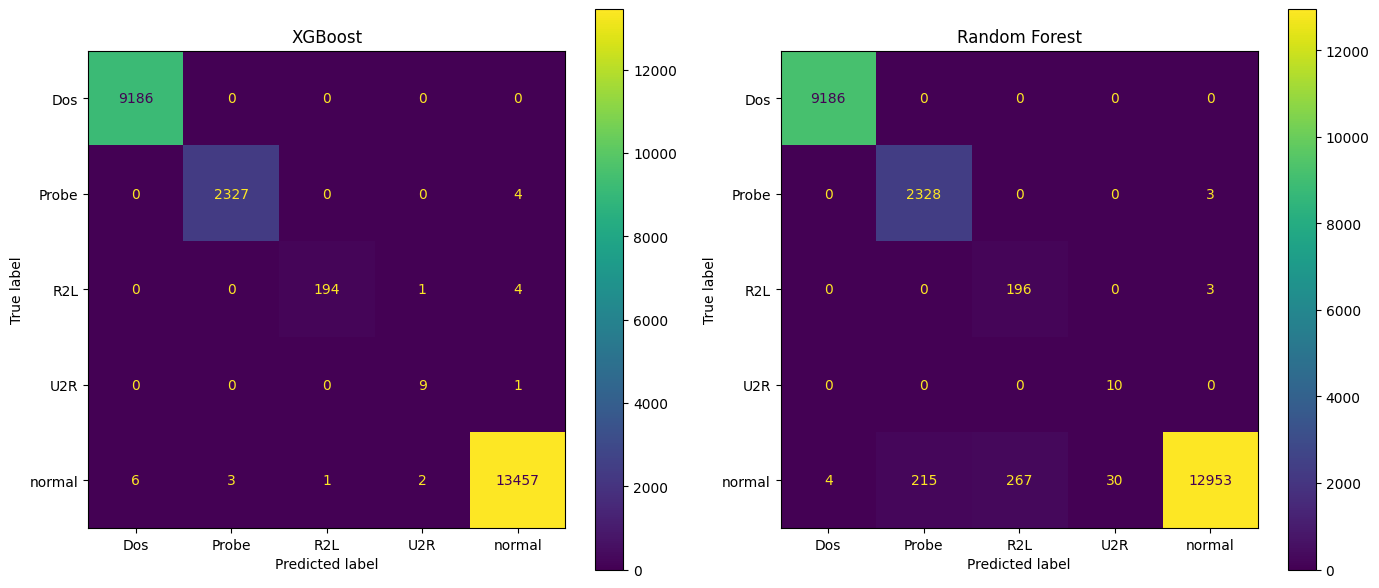

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xg_cm = confusion_matrix(y_test, xg_pred)
ConfusionMatrixDisplay(xg_cm, display_labels=target_names).plot(ax=axes[0])
axes[0].set_title("XGBoost")

rf_cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(rf_cm, display_labels=target_names).plot(ax=axes[1])
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

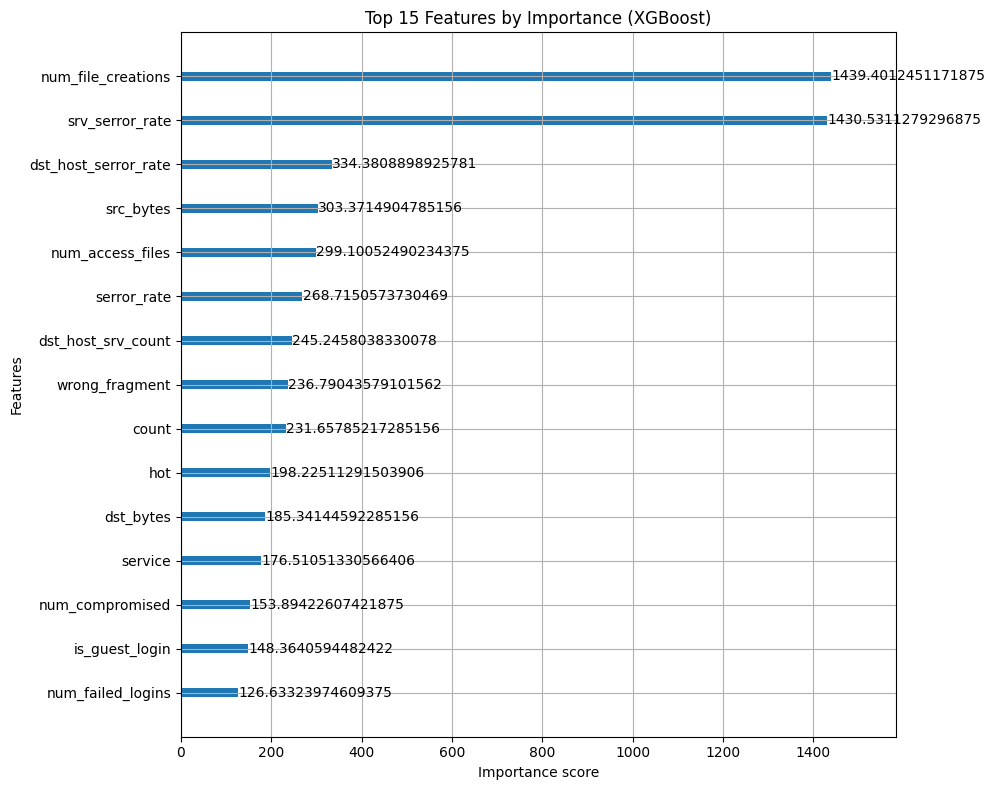

In [39]:
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xg, ax=ax, max_num_features=15, importance_type='gain')
plt.title('Top 15 Features by Importance (XGBoost)')
plt.tight_layout()
plt.show()

In [40]:
df_test_raw = pd.read_csv('/content/KDDTest+.txt')  # or your renamed file
df_test_raw.columns = columns  # reuse the same columns list from earlier

# Keep the true labels before dropping them
true_labels_raw = df_test_raw['attack'].copy()

df_test_raw = df_test_raw.drop(['attack', 'level'], axis=1)

In [41]:
# Group attack labels into categories (Dos/Probe/R2L/U2R/normal)
true_labels_grouped = true_labels_raw.to_frame(name='attack')
change_label(true_labels_grouped)
true_labels_grouped = true_labels_grouped['attack']

# Handle any service categories unseen during training
train_services = set(le_service.classes_)
df_test_raw['service'] = df_test_raw['service'].apply(
    lambda x: x if x in train_services else le_service.classes_[0]
)

# Encode categorical columns using the SAME encoders fit on training data
df_test_raw['protocol_type'] = le_protocol_type.transform(df_test_raw['protocol_type'])
df_test_raw['service'] = le_service.transform(df_test_raw['service'])
df_test_raw['flag'] = le_flag.transform(df_test_raw['flag'])

# Scale using the SAME scaler fit on training data
df_test_raw[numerical_columns] = scaler.transform(df_test_raw[numerical_columns])

# Encode true labels using the same attack encoder
y_true_official = le_attack.transform(true_labels_grouped)

In [42]:
official_preds = xg.predict(df_test_raw)

print("Accuracy on official NSL-KDD test set:", accuracy_score(y_true_official, official_preds))
print()
print(classification_report(y_true_official, official_preds, target_names=list(le_attack.classes_)))

Accuracy on official NSL-KDD test set: 0.779355010424522

              precision    recall  f1-score   support

         Dos       0.96      0.78      0.86      7459
       Probe       0.81      0.82      0.82      2421
         R2L       0.98      0.10      0.19      2885
         U2R       0.67      0.27      0.38        67
      normal       0.69      0.97      0.81      9711

    accuracy                           0.78     22543
   macro avg       0.82      0.59      0.61     22543
weighted avg       0.83      0.78      0.75     22543

